<a href="https://colab.research.google.com/github/stephleao/wmc-bc-data-analytics/blob/main/modulo-08/desafio/analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Probabilidade e Amostragem

Você é uma pesquisadora desenvolvendo uma análise sobre as características da força de trabalho nos estados brasileiros.

In [52]:
# Importa as bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Carregamento da base de dados
arquivo = 'modulo-08/desafio/populacao_brasileira'
df = pd.read_csv(f'https://raw.githubusercontent.com/stephleao/wmc-bc-data-analytics/main/{arquivo}.csv')

# Altera os nomes das colunas e define o index
df = df.rename(columns={
  'Unnamed: 0': 'id',
  'estado': 'uf',
  'nível de proficiência em inglês': 'nivel_ingles',
  'sexo': 'genero',
}).set_index('id')

df.head()

,uf,idade,escolaridade,nivel_ingles,renda,genero
id,,,,,,
0,MA,56,Fundamental,Intermediário,4006.29,F
1,BA,46,Superior,Básico,2423.11,M
2,AM,32,Fundamental,Intermediário,3835.69,M
3,CE,60,Superior,Básico,1870.29,M
4,SE,25,Fundamental,Avançado,3529.80,M


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uf            1000 non-null   object 
 1   idade         1000 non-null   int64  
 2   escolaridade  1000 non-null   object 
 3   nivel_ingles  1000 non-null   object 
 4   renda         1000 non-null   float64
 5   genero        1000 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 54.7+ KB


In [54]:
df.describe()

,idade,renda
count,1000.000000,1000.000000
mean,40.986000,3082.537180
std,13.497852,996.572239
min,18.000000,103.740000
25%,29.000000,2425.815000
50%,42.000000,3076.415000
75%,52.000000,3714.487500
max,64.000000,5632.380000


In [55]:
# Variaveis para reutilizacao

paleta = sns.color_palette("rocket") # paleta de cores
linha_cor = 'darkred'

n = len(df)               # Tamanho da amostra
z = 1.96                  # Z-core
correcao = 0.5            # Correcao de continuidade

faixa_tamanho = 1500          # Tamanho da faixa de renda
ev_renda = df['renda']        # Espaco amostral de renda
renda_min = ev_renda.min()    # Menor renda
renda_max = ev_renda.max()    # Maior renda
renda_media = ev_renda.mean() # Media da renda
renda_var = ev_renda.var()    # Variancia da renda
renda_std = ev_renda.std()    # Desvio padrao da renda

ev_ingles = df['nivel_ingles']        # Espaco amostral de nivel de ingles
ev_uf = df['uf']                      # Espaco amostral da uf/estado

ev_escolaridade = df['escolaridade']  # Espaco amostral de escolaridade
ordem_escolaridade = ['Fundamental',
                      'Médio',
                      'Superior',
                      'Pós-graduação'] # da menor para a maior

## 1. Probabilidade Complementar - Inglês Fluente

Calcular a probabilidade de uma pessoa escolhida aleatoriamente **não** ser fluente (neste caso, "Avançado") em inglês.

In [56]:
ev_ingles_fluente = ev_ingles.isin(['Avançado'])  # Evento A
prob_nao_fluente = 1 - ev_ingles_fluente.mean()   # Probabilidade complementar

print(f'A probabilidade de escolhermos alguém não fluente (prob. complementar) é de {prob_nao_fluente:.2%}.')

A probabilidade de escolhermos alguém não fluente (prob. complementar) é de 65.60%.


## 2. Probabilidade Condicional - Renda > 5k | UF = AL ou PA

Calcular a probabilidade da renda de uma pessoa de Alagoas ou Pará ser superior a R$ 5.000.

In [57]:
df_al_pa = df[ev_uf.isin(['AL', 'PA'])] # Espaço amostral condicionado ao evento B

renda_5k = 5000
# P(A|B), onde a renda e o evento A dentro de B
prob_renda_5k_dado_al_pa = (df_al_pa['renda'] > renda_5k).mean()

print(f'A probabilidade de escolhermos uma pessoa receber R$ {renda_5k} sendo de Alagoas ou do Pará é de {prob_renda_5k_dado_al_pa:.2%}.')

A probabilidade de escolhermos uma pessoa receber R$ 5000 sendo de Alagoas ou do Pará é de 5.06%.


## 3. Distribuição Geométrica - Superior | AM

Calcular a probabilidade condicional de uma pessoa do AM ter Ens. Superior.

In [58]:
ev_am = ev_uf == 'AM' # Evento A
ev_esc_sup = df[ev_am]['escolaridade'] # Evento B
escolaridade_alvo = ordem_escolaridade[2]
prob_am_sup = ev_esc_sup.value_counts(normalize=True)[escolaridade_alvo] # P(A|B) - valor de p
k = 5 # Total de tentativas
prob_am_sup_5 = (1 - prob_am_sup) ** (k - 1) * prob_am_sup

print(f'A probabilidade da 5ª pessoa amazonense ter Ens. {escolaridade_alvo} é de {prob_am_sup_5:.2%}.')

A probabilidade da 5ª pessoa amazonense ter Ens. Superior é de 8.03%.


## 4. Distribuição de Renda - Faixas de R$ 1.500 e FDP

- Agrupar a renda em faixas de R$ 1.500 e identificar qual faixa concentra a maioria das pessoas (faixa modal).
- Plotar o gráfico para representar a Função Densidade de Probabilidade (FDP) da renda.

In [59]:
renda_limites = np.arange(0, renda_max + faixa_tamanho, faixa_tamanho)

# Adiciona coluna categorica com as faixas
df['faixa_renda'] = pd.cut(ev_renda, bins=renda_limites, right=False, include_lowest=True)
# Faz a contagem
contagem_renda = df['faixa_renda'].value_counts()

renda_moda_intervalo = contagem_renda.idxmax()
print(f'A renda da maioria ({contagem_renda.max()} pessoas) está na faixa de R$ {renda_moda_intervalo.left:.2f} - {renda_moda_intervalo.right:.2f}.\n')

A renda da maioria (442 pessoas) está na faixa de R$ 3000.00 - 4500.00.



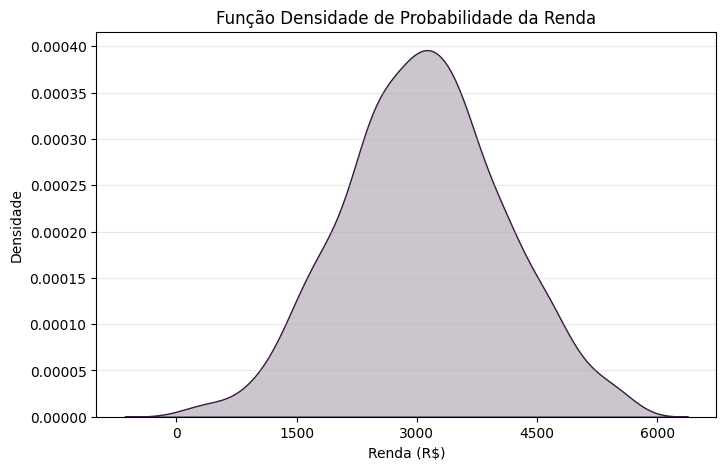

In [60]:
# Plota o grafico com a FDP
plt.figure(figsize=(8, 5))
sns.kdeplot(ev_renda,
            fill=True,
            color=paleta[0])
plt.xticks(renda_limites)
plt.title('Função Densidade de Probabilidade da Renda')
plt.ylabel('Densidade')
plt.xlabel('Renda (R$)')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 5. Estatísticas da Renda e Distribuição Normal

- Calcular a média, variância amostral desvio padrão da coluna de renda.
- Plotar o histograma da densidade e sobrepor a curva da distribuição Normal teórica com os parâmetros calculados.

In [61]:
print(f'Média de renda da amostra: {renda_media:.2f}')
print(f'Variância da renda da amostra: {renda_var:.2f}')
print(f'Desvio padrão da renda da amostra: {renda_std:.2f}')

Média de renda da amostra: 3082.54
Variância da renda da amostra: 993156.23
Desvio padrão da renda da amostra: 996.57


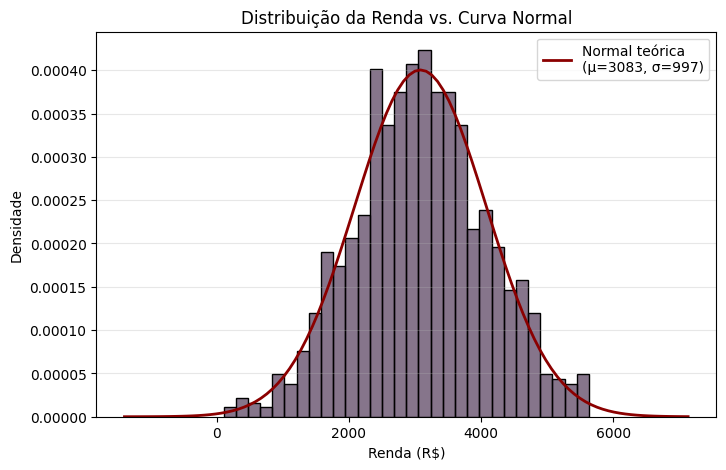

In [62]:
plt.figure(figsize=(8, 5))
sns.histplot(ev_renda,
             bins=30,
             color=paleta[0],
             alpha=0.6,
             stat='density')

# Linha da Distribuicao Normal Teorica
x = np.linspace(renda_min - faixa_tamanho, renda_max + faixa_tamanho, 100)
y = norm.pdf(x, renda_media, renda_std)
plt.plot(x, y,
         color=linha_cor,
         linewidth=2,
         label=f'Normal teórica\n(μ={renda_media:.0f}, σ={renda_std:.0f})')
plt.title('Distribuição da Renda vs. Curva Normal')
plt.ylabel('Densidade')
plt.xlabel('Renda (R$)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 6. Aproximação Normal para Proporção - Pós-graduação em 1 Milhão

- Calcular a proporção amostral de pessoas com pós-graduação.
- Supondo uma população de 1.000.000 de pessoas, calcular a probabilidade de encontrar exatamente 243.000 pessoas com pós-graduação, utilizando a aproximação normal da binomial.

In [63]:
# Probabilidade de pos-graduacao
prob_posgrad = ev_escolaridade.isin([ordem_escolaridade[3]]).mean()

n_1m = 1000000  # 1 milhao de habitantes
k = 243000      # O valor que queremos encontrar

# Parametros da distribuicao normal (binomial)
med_binom_posgrad = n_1m * prob_posgrad
std_1m = np.sqrt(med_binom_posgrad * (1 - prob_posgrad))

# Probabilidade de encontrar exatamente 243.000
prob_exata_posgrad = norm.cdf(k + correcao, med_binom_posgrad, std_1m) - norm.cdf(k - correcao, med_binom_posgrad, std_1m)

zcore = (k - med_binom_posgrad) / std_1m

print(f"Com uma taxa estimada de {prob_posgrad:.1%} e um Z-core de {zcore:.0f}, a probabilidade de encontrar exatamente {k} pós-graduados é de {prob_exata_posgrad:.2%}.")

Com uma taxa estimada de 25.3% e um Z-core de -23, a probabilidade de encontrar exatamente 243000 pós-graduados é de 0.00%.


## 7. Função de Densidade Acumulada (FDA) para Escolaridade

Calcular a densidade (proporção) da coluna 'Escolaridade' organizada por ordem de nível de instrução e, em seguida, calcular a FDA (soma cumulativa das densidades).

In [64]:
# Calcula a probabilidade e coloca na ordem estabelecida
fda_escolaridade = ev_escolaridade.value_counts(normalize=True).reindex(ordem_escolaridade).to_frame()
# Calcula a FDA
fda_escolaridade['FDA'] = fda_escolaridade.cumsum()
fda_escolaridade

,proportion,FDA
escolaridade,,
Fundamental,0.266,0.266
Médio,0.238,0.504
Superior,0.243,0.747
Pós-graduação,0.253,1.000


## 8. Margem de Erro - Inglês Intermediário

Com base na proporção amostral de pessoas com nível de inglês "Intermediário", calcular a margem de erro para um intervalo de confiança de 95% (z=1.96).

In [65]:
p_amostral = ev_ingles.value_counts(normalize=True) # proporcao amostral

# Calcula a margem de erro
me = z * np.sqrt((p_amostral * (1 - p_amostral)) / n)

# Extrai o valor de  Intermediario
nivel_alvo = 'Intermediário'
p_ing_intmd = p_amostral.loc[nivel_alvo]
me_ing_intmd = me.loc[nivel_alvo]

print(f'Proporção amostral de pessoas com inglês intermediário: {p_ing_intmd:.2%}')
print(f'Margem de erro (95% de confiança): ± {me_ing_intmd:.2%}')

Proporção amostral de pessoas com inglês intermediário: 32.90%
Margem de erro (95% de confiança): ± 2.91%


## 9. Aproximação Normal - Renda > Média + R$ 1.000, k = 60

Calcular a probabilidade de encontrar exatamente 60 pessoas com renda R$ 1.000 superior à média. (Utilizar a aproximação normal com correção de continuidade.)

In [66]:
renda_alvo = renda_media + 1000

# Probabilidade de encontrar alguem com a renda alvo
prob_renda_alvo = (ev_renda > renda_alvo).mean()

# O valor que queremos encontrar
k = 60

# Parametros da distribuicao normal (binomial)
med_binom_renda_alvo = n * prob_renda_alvo
std_renda_alvo = np.sqrt(med_binom_renda_alvo * (1 - prob_renda_alvo))

# Probabilidade de encontrar exatamente 60
prob_exata_posgrad = norm.cdf(k + correcao, med_binom_renda_alvo, std_renda_alvo) - norm.cdf(k - correcao, med_binom_renda_alvo, std_renda_alvo)
zscore = (k - med_binom_renda_alvo) / std_renda_alvo

print(f'Com uma taxa estimada de {prob_renda_alvo:.1%} e um z-score de {zscore:.0f}, a probabilidade de encontrar exatamente {k} pessoas com renda de R$ {renda_alvo:.2f} é de {prob_exata_posgrad:.2%}.')

Com uma taxa estimada de 16.1% e um z-score de -9, a probabilidade de encontrar exatamente 60 pessoas com renda de R$ 4082.54 é de 0.00%.


## 10. Probabilidade Conjunta - Sudeste ∩ Homem ∩ Fundamental ∩ Renda > 2k

Calcular a probabilidade de uma pessoa escolhida aleatoriamente ser homem do Sudeste e ter Ens. Fundamental e renda superior a R$ 2.000.

In [67]:
renda_2k = 2000
escolaridade_alvo = ordem_escolaridade[0]

ev_sudeste = ev_uf.isin(['ES', 'MG', 'RJ', 'SP'])     # Evento A
ev_homem = df['genero'] == 'M'                        # Evento B
ev_fundamental = ev_escolaridade == escolaridade_alvo # Evento C
ev_renda_2k = ev_renda > renda_2k                     # Evento D

# P(A&B&C&D)
prob_sud_hom_fund_2k = ((ev_sudeste) & (ev_homem) & (ev_fundamental) & (ev_renda_2k)).mean()

print(f'A probabilidade de escolhermos um homem do Sudeste com Ens. {escolaridade_alvo} e renda de mais de R$ {renda_2k} é de {prob_sud_hom_fund_2k:.2%}.')

A probabilidade de escolhermos um homem do Sudeste com Ens. Fundamental e renda de mais de R$ 2000 é de 1.90%.
